# 06 · What makes a property, and a suburb, more expensive or sought after (Sprints 3–4)

Two levels:

* **Property level** (Sprint 3): which features of a listing go with a higher rent, *holding everything else
  equal* (same number of bedrooms, same type, same distance to the CBD, same local income...).
* **Suburb level** (Sprint 4): which suburb characteristics go with higher rents and with being **sought after**.
  "Sought after" is measured by **days on the market**: a suburb where rentals are leased quickly is in demand.

Input: `listings_features.parquet` and `suburb_features.parquet` from notebook 05b. Every snapshot in those files is
used; with more than one snapshot a snapshot term is added so 2025 and 2026 rents can differ.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # shared project code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config, style
import listings as L
style.apply()
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_parquet(config.LISTINGS_FEATURES)
need = ["bedrooms", "bathrooms", "cbd_route_km", "train_route_km", "MEDIAN_INCOME_2022_23", "POP_GROWTH_2020_2025"]
use = df[df["usable"]].dropna(subset=need).copy()
use["log_rent"] = np.log(use["weekly_rent"])
use["carspaces_missing"] = use["carspaces"].isna().astype(int)
use["carspaces"] = use["carspaces"].fillna(0).clip(upper=6)
use["bathrooms"] = use["bathrooms"].clip(upper=6)
print(f"{len(use):,} listings used ({use['snapshot'].nunique()} snapshot(s))")

12,288 listings used (1 snapshot(s))


## 1. Property level: rent premium of each feature

A regression of log weekly rent on the property's size and type, its location (income of the area, driving
distance to the CBD and a station, nearby amenities) and each listed feature. Because rent is in logs, each
feature's coefficient converts to a **percentage premium**: "a listing that mentions X rents for about N% more
than an otherwise similar listing". Features that agents list mainly on cheaper or more expensive properties can
still carry some of that, so read these as associations, not guaranteed effects.

R² = 0.583 on 12,288 listings


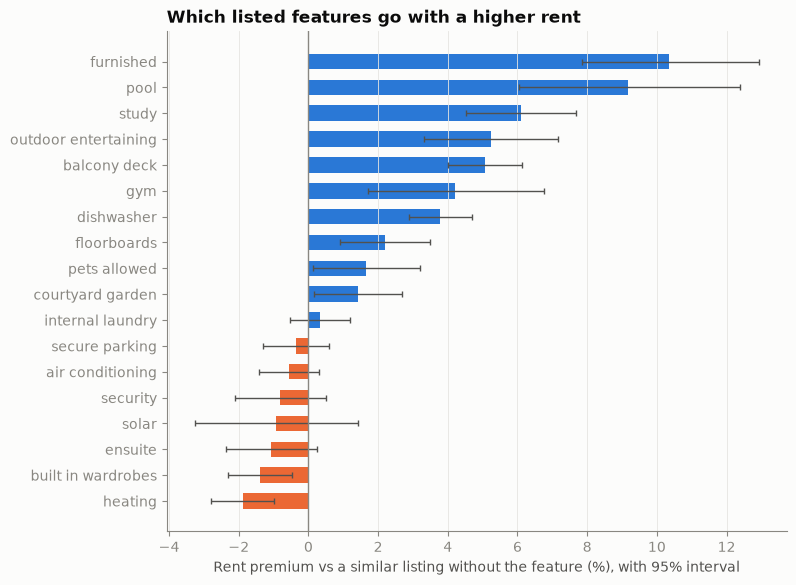

,premium_pct,low,high,p_value
heating,-1.890,-2.796,-0.976,0.000
built in wardrobes,-1.397,-2.311,-0.474,0.003
ensuite,-1.066,-2.359,0.245,0.111
solar,-0.941,-3.258,1.430,0.433
security,-0.810,-2.112,0.508,0.227
air conditioning,-0.557,-1.416,0.311,0.208
secure parking,-0.365,-1.303,0.582,0.449
internal laundry,0.332,-0.519,1.191,0.445
courtyard garden,1.416,0.161,2.687,0.027
pets allowed,1.654,0.122,3.209,0.034


In [3]:
formula = ("log_rent ~ C(property_group, Treatment('Apartment/Unit')) + bedrooms + bathrooms + carspaces"
           " + carspaces_missing + np.log(MEDIAN_INCOME_2022_23) + np.log1p(cbd_route_km)"
           " + np.log1p(train_route_km) + np.log1p(entertainment_within_1km) + np.log1p(shops_within_2km)"
           " + np.log1p(park_km) + np.log1p(school_km) + POP_GROWTH_2020_2025 + features_missing + "
           + " + ".join(L.FEATURE_COLUMNS))
if use["snapshot"].nunique() > 1:
    formula += " + C(snapshot)"
ols = smf.ols(formula, data=use).fit(cov_type="HC1")
print(f"R² = {ols.rsquared:.3f} on {int(ols.nobs):,} listings")

ci = ols.conf_int()
prem = pd.DataFrame({"premium_pct": (np.exp(ols.params) - 1) * 100,
                     "low": (np.exp(ci[0]) - 1) * 100, "high": (np.exp(ci[1]) - 1) * 100,
                     "p_value": ols.pvalues})
feat = prem.loc[L.FEATURE_COLUMNS].sort_values("premium_pct")
feat.index = feat.index.str.replace("has_", "").str.replace("_", " ")

fig, ax = plt.subplots(figsize=(8, 6.5))
colours = [style.BLUE if v > 0 else style.ORANGE for v in feat["premium_pct"]]
ax.barh(feat.index, feat["premium_pct"], color=colours, height=0.6)
ax.errorbar(feat["premium_pct"], feat.index, xerr=[feat["premium_pct"] - feat["low"], feat["high"] - feat["premium_pct"]],
            fmt="none", ecolor=style.INK_2, elinewidth=1, capsize=2)
ax.axvline(0, color=style.MUTED, linewidth=1)
ax.set_xlabel("Rent premium vs a similar listing without the feature (%), with 95% interval")
ax.set_title("Which listed features go with a higher rent")
ax.grid(axis="y", visible=False)
fig.savefig(config.PLOTS / "feature_rent_premium.png", dpi=150, bbox_inches="tight")
plt.show()
feat.round(3)

**How the size and location terms read** (same regression):

In [4]:
def effect(term, how):
    b = ols.params[term]
    return {"per unit": (np.exp(b) - 1) * 100, "doubling": (2 ** b - 1) * 100,
            "+10%": (1.1 ** b - 1) * 100}[how]

rows = [
    ("House instead of apartment/unit", "C(property_group, Treatment('Apartment/Unit'))[T.House]", "per unit"),
    ("Townhouse instead of apartment/unit", "C(property_group, Treatment('Apartment/Unit'))[T.Townhouse]", "per unit"),
    ("One more bedroom", "bedrooms", "per unit"),
    ("One more bathroom", "bathrooms", "per unit"),
    ("One more car space", "carspaces", "per unit"),
    ("Area median income 10% higher", "np.log(MEDIAN_INCOME_2022_23)", "+10%"),
    ("Driving distance to CBD doubles", "np.log1p(cbd_route_km)", "doubling"),
    ("Driving distance to station doubles", "np.log1p(train_route_km)", "doubling"),
    ("Entertainment venues within 1 km double", "np.log1p(entertainment_within_1km)", "doubling"),
]
pd.DataFrame([(name, round(effect(t, how), 1), f"{ols.pvalues[t]:.3g}") for name, t, how in rows],
             columns=["change", "rent change (%)", "p-value"])

,change,rent change (%),p-value
0,House instead of apartment/unit,-0.0,0.996
1,Townhouse instead of apartment/unit,6.2,3e-12
2,One more bedroom,16.2,9.58e-98
3,One more bathroom,14.4,6.72e-79
4,One more car space,2.6,1.63e-08
5,Area median income 10% higher,2.6,1.73e-91
6,Driving distance to CBD doubles,-6.8,2.6e-221
7,Driving distance to station doubles,0.7,0.00213
8,Entertainment venues within 1 km double,3.9,2.28e-130


## 2. Property level: which inputs matter most for predicting rent

A gradient-boosted tree model (it can capture curves and interactions the regression cannot) is trained on 80% of
listings and tested on the other 20%. **Permutation importance** shuffles one input at a time and measures how much
worse the predictions get: the bigger the drop, the more the model relies on that input.

Test R² = 0.758  (regression above: 0.583)
Median absolute error on unseen listings: 7.6% of rent


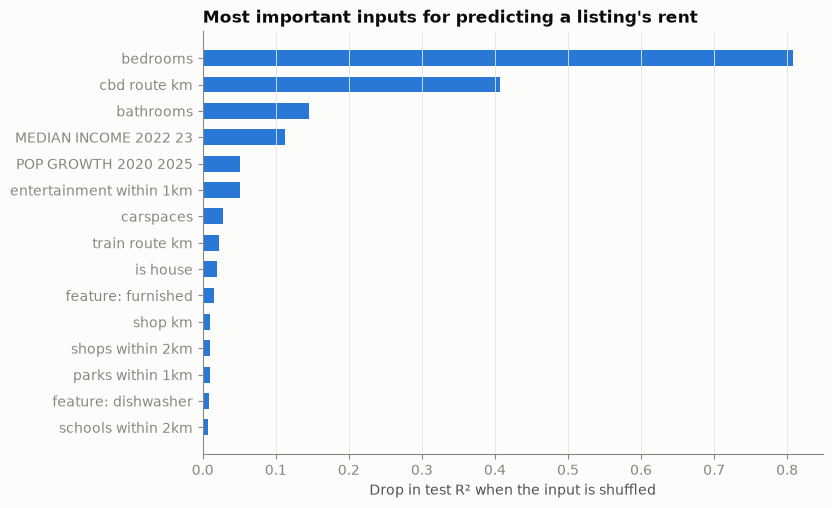

In [5]:
X_cols = ["bedrooms", "bathrooms", "carspaces", "MEDIAN_INCOME_2022_23", "POP_GROWTH_2020_2025",
          "cbd_route_km", "train_route_km", "school_km", "park_km", "shop_km", "entertainment_within_1km",
          "shops_within_2km", "schools_within_2km", "parks_within_1km"] + L.FEATURE_COLUMNS
X = use[X_cols].assign(is_house=(use["property_group"] == "House").astype(int),
                       is_townhouse=(use["property_group"] == "Townhouse").astype(int),
                       is_studio=(use["property_group"] == "Studio").astype(int))
X_tr, X_te, y_tr, y_te = train_test_split(X, use["log_rent"], test_size=0.2, random_state=0)
gbm = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=0).fit(X_tr, y_tr)
print(f"Test R² = {gbm.score(X_te, y_te):.3f}  (regression above: {ols.rsquared:.3f})")
err = np.exp(gbm.predict(X_te)) / np.exp(y_te) - 1
print(f"Median absolute error on unseen listings: {np.median(np.abs(err)) * 100:.1f}% of rent")

imp = permutation_importance(gbm, X_te, y_te, n_repeats=5, random_state=0)
top = pd.Series(imp.importances_mean, index=X.columns).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index.str.replace("has_", "feature: ").str.replace("_", " "), top.values, color=style.BLUE, height=0.6)
ax.set_xlabel("Drop in test R² when the input is shuffled")
ax.set_title("Most important inputs for predicting a listing's rent")
ax.grid(axis="y", visible=False)
fig.savefig(config.PLOTS / "listing_rent_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Suburb level: what makes a suburb expensive or sought after (Sprint 4)

One row per suburb (suburbs with at least 10 usable listings). Two outcomes:

* **median weekly rent** (expensive), and
* **median days on the market** (sought after: *fewer* days = more sought after).

The chart shows the rank correlation (Spearman) of each suburb characteristic with each outcome. Then a
regression with all characteristics together, standardised so the bars are comparable: each bar is the change in
the outcome for a one-standard-deviation increase in that characteristic, holding the others fixed.

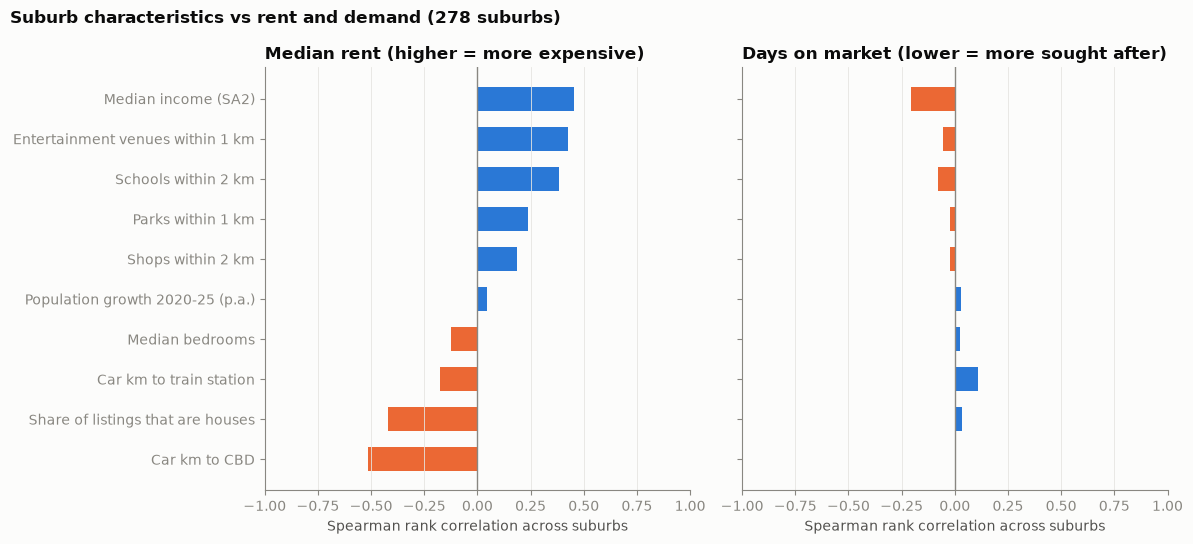

,Median rent,Days on market
Car km to CBD,-0.52,0.00
Share of listings that are houses,-0.42,0.03
Car km to train station,-0.18,0.11
Median bedrooms,-0.12,0.03
Population growth 2020-25 (p.a.),0.05,0.03
Shops within 2 km,0.19,-0.02
Parks within 1 km,0.24,-0.02
Schools within 2 km,0.38,-0.08
Entertainment venues within 1 km,0.43,-0.05
Median income (SA2),0.45,-0.21


In [6]:
sub = pd.read_parquet(config.SUBURB_FEATURES)
sub = sub[sub["listings"] >= 10].copy()
names = {
    "MEDIAN_INCOME_2022_23": "Median income (SA2)",
    "cbd_route_km": "Car km to CBD",
    "train_route_km": "Car km to train station",
    "entertainment_within_1km": "Entertainment venues within 1 km",
    "shops_within_2km": "Shops within 2 km",
    "schools_within_2km": "Schools within 2 km",
    "parks_within_1km": "Parks within 1 km",
    "POP_GROWTH_2020_2025": "Population growth 2020-25 (p.a.)",
    "POP_PROJ_GROWTH_2026_2031": "Projected population growth to 2031",
    "share_house": "Share of listings that are houses",
    "median_bedrooms": "Median bedrooms",
}
if sub["POP_PROJ_SOURCE"].str.startswith("ABS ERP").all():   # projection is just the past trend: keep one
    names.pop("POP_PROJ_GROWTH_2026_2031")
corr = pd.DataFrame({
    "Median rent": sub[list(names)].corrwith(sub["median_rent"], method="spearman"),
    "Days on market": sub[list(names)].corrwith(sub["median_days_listed"], method="spearman"),
}).rename(index=names).sort_values("Median rent")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
for ax, col, note in zip(axes, corr.columns, ["higher = more expensive", "lower = more sought after"]):
    ax.barh(corr.index, corr[col], color=[style.BLUE if v > 0 else style.ORANGE for v in corr[col]], height=0.6)
    ax.axvline(0, color=style.MUTED, linewidth=1)
    ax.set_xlim(-1, 1)
    ax.set_title(f"{col} ({note})")
    ax.set_xlabel("Spearman rank correlation across suburbs")
    ax.grid(axis="y", visible=False)
fig.suptitle(f"Suburb characteristics vs rent and demand ({len(sub)} suburbs)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(config.PLOTS / "suburb_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
corr.round(2)

In [7]:
z = sub[list(names)].copy()
z["cbd_route_km"] = np.log1p(z["cbd_route_km"])
z["train_route_km"] = np.log1p(z["train_route_km"])
z["entertainment_within_1km"] = np.log1p(z["entertainment_within_1km"])
z = (z - z.mean()) / z.std()
z.columns = [f"x{i}" for i in range(len(names))]
data = z.assign(log_rent=np.log(sub["median_rent"]), days=sub["median_days_listed"]).dropna()
terms = " + ".join(z.columns)
fits = {"Median rent (% per 1 SD)": smf.ols(f"log_rent ~ {terms}", data=data).fit(cov_type="HC1"),
        "Days on market (days per 1 SD)": smf.ols(f"days ~ {terms}", data=data).fit(cov_type="HC1")}
table = pd.DataFrame({
    "Median rent (% per 1 SD)": (np.exp(fits["Median rent (% per 1 SD)"].params[z.columns]) - 1) * 100,
    "p (rent)": fits["Median rent (% per 1 SD)"].pvalues[z.columns],
    "Days on market (days per 1 SD)": fits["Days on market (days per 1 SD)"].params[z.columns],
    "p (days)": fits["Days on market (days per 1 SD)"].pvalues[z.columns],
})
table.index = list(names.values())
print(f"R²: rent {fits['Median rent (% per 1 SD)'].rsquared:.2f}, days on market {fits['Days on market (days per 1 SD)'].rsquared:.2f}  ({len(data)} suburbs)")
table.sort_values("Median rent (% per 1 SD)", ascending=False).round(3)

R²: rent 0.45, days on market 0.04  (278 suburbs)


,Median rent (% per 1 SD),p (rent),Days on market (days per 1 SD),p (days)
Median bedrooms,13.838,0.000,0.174,0.896
Entertainment venues within 1 km,7.224,0.001,2.403,0.324
Median income (SA2),4.436,0.001,-1.693,0.011
Car km to train station,2.759,0.036,0.452,0.526
Schools within 2 km,1.140,0.497,0.281,0.838
Parks within 1 km,-1.633,0.166,-0.503,0.353
Shops within 2 km,-2.694,0.042,-0.841,0.333
Population growth 2020-25 (p.a.),-3.942,0.000,0.740,0.068
Share of listings that are houses,-4.630,0.015,0.383,0.722
Car km to CBD,-8.866,0.000,0.489,0.843


### Most expensive and most sought-after suburbs (latest snapshot, at least 10 listings)

In [8]:
latest = sub[sub["snapshot"] == sub["snapshot"].max()]
show = ["suburb", "listings", "median_rent", "median_days_listed", "MEDIAN_INCOME_2022_23", "cbd_route_km",
        "train_route_km", "entertainment_within_1km"]
print("Most expensive (median weekly rent)")
display(latest.nlargest(10, "median_rent")[show].round(1).reset_index(drop=True))
print("Most sought after (fewest median days on market)")
display(latest.nsmallest(10, "median_days_listed")[show].round(1).reset_index(drop=True))

Most expensive (median weekly rent)


,suburb,listings,median_rent,median_days_listed,MEDIAN_INCOME_2022_23,cbd_route_km,train_route_km,entertainment_within_1km
0,BRIGHTON,54,1595.0,49.0,75139.0,13.0,1.0,25.5
1,BRIGHTON EAST,25,1190.0,19.0,69612.0,14.1,2.2,3.0
2,BLACK ROCK,10,1175.0,14.5,68884.0,20.8,3.5,7.0
3,MCKINNON,12,1100.0,11.0,67586.0,15.7,0.2,15.5
4,SANDRINGHAM,20,1050.0,12.5,68884.0,19.2,1.4,21.0
5,BEAUMARIS,14,960.0,13.0,67712.0,23.4,2.9,11.0
6,PORT MELBOURNE,81,950.0,22.0,84478.0,5.7,4.1,52.0
7,BALWYN NORTH,27,930.0,14.0,57356.0,13.9,4.0,12.0
8,FITZROY,28,892.5,8.0,71663.0,3.0,2.1,319.0
9,MOUNT MARTHA,14,890.0,29.0,56992.0,76.9,20.1,0.0


Most sought after (fewest median days on market)


,suburb,listings,median_rent,median_days_listed,MEDIAN_INCOME_2022_23,cbd_route_km,train_route_km,entertainment_within_1km
0,BACCHUS MARSH,11,460.0,6.0,62129.0,59.5,3.3,0.0
1,LANGWARRIN,11,600.0,6.0,61979.0,56.9,5.0,2.0
2,CAULFIELD SOUTH,11,725.0,7.0,68409.0,12.5,2.2,31.0
3,HIGHETT,13,650.0,7.0,65857.0,18.5,0.5,22.0
4,HILLSIDE,16,545.0,7.0,61663.0,27.7,3.9,4.0
5,LEOPOLD,17,520.0,7.0,55483.0,85.6,11.5,0.0
6,WANGARATTA,11,480.0,7.0,52675.0,240.6,1.0,1.0
7,WESTMEADOWS,12,560.0,7.0,58454.0,18.0,2.9,0.5
8,BONBEACH,12,555.0,7.5,67778.0,32.9,0.7,4.0
9,CHELSEA,14,575.0,7.5,67778.0,31.8,0.8,21.0
